In [2]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("emulation_data/ffmpeg_summary_v2.csv")
df = df.sort_values(by=["cpu-allocated", "resolution", "num_task"])

# Change time-elapsed to 
# df["time-elapsed"] = (120 * 30 / df["avg-fps"]).apply(lambda x: float(f"{x:.2f}"))

In [4]:
df = pd.read_csv("emulation_data/ffmpeg_summary.csv")
df = df.sort_values(by=["cpu-allocated", "resolution", "num_task"])
df.loc[df["cpu-allocated"] == 15,"memory_allocated"] = 16384


FileNotFoundError: [Errno 2] No such file or directory: 'emulation_data/ffmpeg_summary.csv'

In [6]:
df["tc_per_sec"] = (df["task-clock(ms)"] * df["num_task"] / df["time-elapsed"]).apply(lambda x: float(f"{x:.2f}"))
df["tc_per_frame"] = (df["task-clock(ms)"] / (df["time-elapsed"] * df["avg-fps"])).apply(lambda x: float(f"{x:.2f}"))
df["mem_per_task"] = ((df["memory_allocated"] * df["avg-system-Memory(%)"] * 0.01) / df["num_task"]).apply(lambda x: float(f"{x:.2f}"))

In [ ]:
# df.to_csv("emulation_data/ffmpeg_summary_sorted.csv")

<Axes: ylabel='Frequency'>

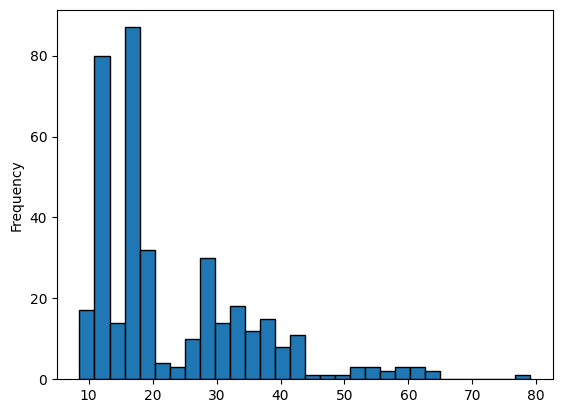

In [8]:
# Plot y-axis = tc_per_frame || x-axis = num_task
df.loc[df["cpu-allocated"] == 10, "tc_per_frame"].plot.hist(bins=30, edgecolor='black')

### Resolution Comparison

In [40]:
df = pd.read_csv("emulation_data/ffmpeg_summary_sorted.csv")

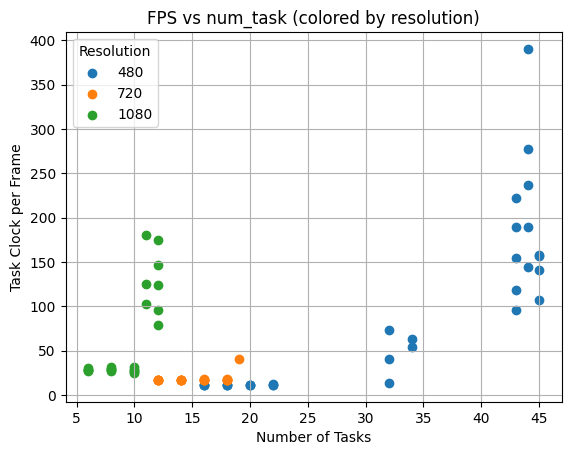

In [98]:
import matplotlib.pyplot as plt

# Filter your data
subset = df.loc[(df["cpu-allocated"] == 5) & (df["memory_allocated"] == 4)]
avg_df = subset.groupby(["resolution", "num_task"], as_index=False).mean()


# Plot manually with different colors for each resolution
fig, ax = plt.subplots()

for label, group in subset.groupby("resolution"):
    # ax.scatter(group["num_task"], group["mem_per_task"], label=label)
    ax.scatter(group["num_task"], group["tc_per_frame"], label=label)

ax.set_title("FPS vs num_task (colored by resolution)")
ax.set_xlabel("Number of Tasks")
ax.set_ylabel("Task Clock per Frame")
# ax.set_ylim(8,25)
ax.grid(True)
ax.legend(title="Resolution")
plt.show()

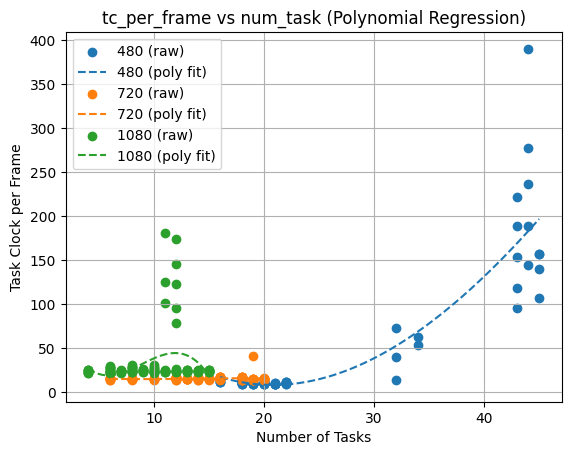

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import Polynomial
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Choose polynomial degree (start with 2 or 3)
poly_degree = 3

subset = df[df["cpu-allocated"] == 5]

# subset = df[df["memory_allocated"] == 5]
fig, ax = plt.subplots()

for label, group in subset.groupby("resolution"):
    x = group["num_task"].values.reshape(-1, 1)
    y = group["tc_per_frame"].values

    # Polynomial features
    poly = PolynomialFeatures(degree=poly_degree)
    X_poly = poly.fit_transform(x)

    # Fit polynomial regression
    model = LinearRegression()
    model.fit(X_poly, y)

    # Predict over a smooth range
    x_fit = np.linspace(min(x), max(x), 100).reshape(-1, 1)
    y_fit = model.predict(poly.transform(x_fit))

    # Plot raw and fitted data
    ax.scatter(x, y, label=f"{label} (raw)")
    ax.plot(x_fit, y_fit, linestyle='--', label=f"{label} (poly fit)")

ax.set_title("tc_per_frame vs num_task (Polynomial Regression)")
ax.set_xlabel("Number of Tasks")
ax.set_ylabel("Task Clock per Frame")
ax.grid(True)
ax.legend()
plt.show()

### CPU Comparison

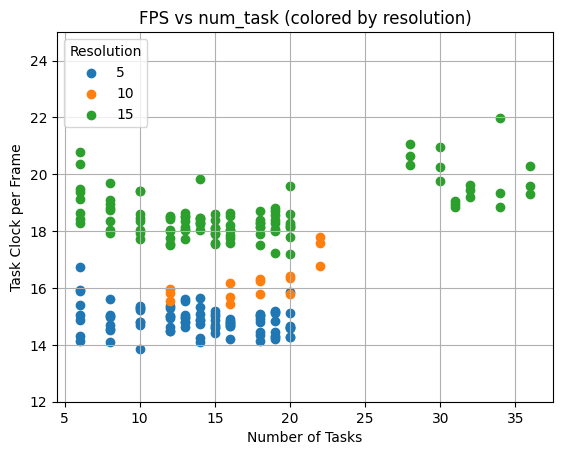

In [33]:
# Filter your data
subset = df.loc[df["resolution"] == 720]

# Plot manually with different colors for each resolution
fig, ax = plt.subplots()

for label, group in subset.groupby("cpu-allocated"):
    # ax.scatter(group["num_task"], group["mem_per_task"], label=label)
    ax.scatter(group["num_task"], group["tc_per_frame"], label=label)

ax.set_title("FPS vs num_task (colored by resolution)")
ax.set_xlabel("Number of Tasks")
ax.set_ylabel("Task Clock per Frame")
ax.set_ylim(12,25)
ax.grid(True)
ax.legend(title="Resolution")
plt.show()

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Let's assume df is your DataFrame
features = ["num_task", "cpu-allocated", "memory_allocated", "resolution"]

# Encode resolution if it's categorical (e.g., "720p", "1080p")
# if df["resolution"].dtype == object:
    # df["resolution"] = df["resolution"].astype("category").cat.codes
    
X = df[features]
y = df["tc_per_frame"]
# y = df["mem_per_task"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.4f}")

Test MSE: 16.1701


/home/vincent/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/vincent/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/vincent/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


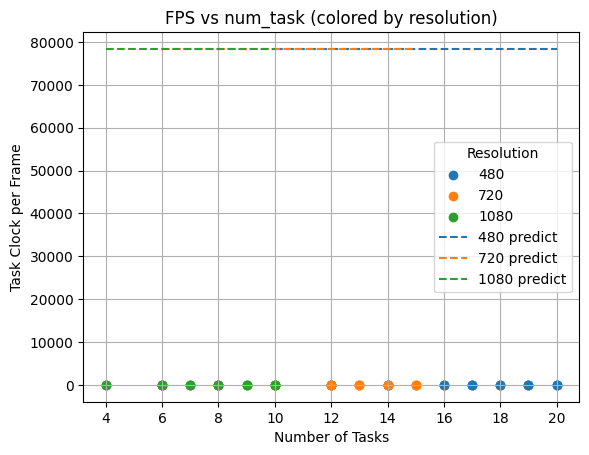

In [ ]:
import matplotlib.pyplot as plt

# Filter your data
subset = df.loc[df["cpu-allocated"] == 10]

# Plot manually with different colors for each resolution
fig, ax = plt.subplots()

for label, group in subset.groupby("resolution"):
    ax.scatter(group["num_task"], group["tc_per_frame"], label=label)
    # ax.scatter(group["num_task"], group["mem_per_task"], label=label)
    
for label, group in subset.groupby("resolution"):
    pred = model.predict(group[features])
    ax.plot(group["num_task"], pred, linestyle="--",  label=str(label) + " predict")

ax.set_title("FPS vs num_task (colored by resolution)")
ax.set_xlabel("Number of Tasks")
ax.set_ylabel("Task Clock per Frame")
ax.grid(True)
ax.legend(title="Resolution")
plt.show()

### Averaging

In [16]:
grouped_avg = df.groupby(["cpu-allocated", "memory_allocated", "resolution", "num_task"], as_index=False).mean()
grouped_avg

,cpu-allocated,memory_allocated,resolution,num_task,time-elapsed,task-clock(ms),context-switches,cpu-migrations,page-faults,avg-fps,avg-q,avg-bitrate(kbits/s),avg-process-CPU(%),avg-process-Memory(MB),avg-system-CPU(%),avg-system-Memory(%),frame_generated,tc_per_sec,tc_per_frame,mem_per_task
0,5,4101222400,1080,11,1290.806667,170013.150000,776362.820000,131644.243333,722016.610000,1.370000,24.116667,0.0,57.196667,326.490000,95.670000,94.183333,2093.664949,1889.120000,136.030000,3.511516e+08
1,5,4101230592,480,16,128.163333,39718.533333,40571.686667,2479.250000,20048.810000,27.296667,23.856667,0.0,31.070000,159.083333,98.393333,63.543333,3508.569805,4958.433333,11.353333,1.628787e+08
2,5,4101230592,480,18,143.673333,39661.023333,40283.223333,2511.833333,21062.963333,24.266667,23.910000,0.0,27.670000,159.250000,98.636667,70.033333,3503.871506,4968.890000,11.376667,1.595682e+08
3,5,4101230592,480,20,159.263333,39550.026667,40299.900000,2453.983333,20502.783333,21.756667,23.896667,0.0,24.886667,158.866667,98.840000,76.160000,3493.072271,4966.696667,11.416667,1.561749e+08
4,5,4101230592,480,22,176.860000,40127.776667,40492.016667,2462.546667,21595.213333,19.683333,23.896667,0.0,22.706667,156.703333,99.006667,82.500000,3504.973299,4991.606667,11.530000,1.537961e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,15,16763293696,1080,20,146.710000,110847.894000,157769.480000,3982.320000,42043.960000,23.504000,23.812000,0.0,75.758000,771.980000,98.682000,92.002000,3486.758825,15110.716000,32.150000,7.711283e+08
170,15,16763293696,1080,21,168.002000,121709.538000,163130.430000,4126.316000,45789.742000,20.068000,23.852000,0.0,72.672000,749.630000,98.854000,95.860000,3451.122425,15213.604000,36.142000,7.652044e+08
171,15,16763293696,1080,22,154.684000,111177.860000,154234.864000,3852.766000,53049.480000,19.480000,23.530000,0.0,72.194000,731.176000,97.784000,95.520000,3266.082169,15812.262000,36.918000,7.278317e+08
172,15,16763293696,1080,23,149.056000,106380.904000,148669.644000,3794.538000,55468.166000,17.514000,23.138000,0.0,71.434000,723.168000,96.342000,94.986000,3045.539648,16414.960000,40.804000,6.922949e+08


In [21]:
grouped_avg.to_csv("./emulation_data/grouped.csv")

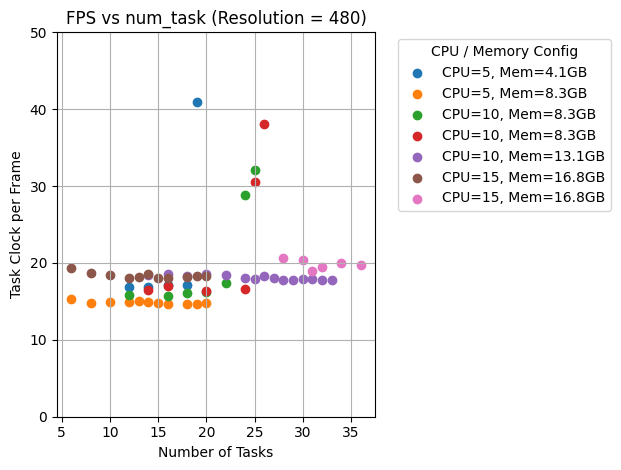

In [39]:
import matplotlib.pyplot as plt

# Filter only resolution = 480
subset = grouped_avg.loc[grouped_avg["resolution"] == 720]

# Get all unique (cpu, memory) pairs and assign colors
cpu_mem_pairs = subset[["cpu-allocated", "memory_allocated"]].drop_duplicates().values
colors = plt.cm.tab10.colors  # Adjust if >10 configs
pair_to_color = {tuple(pair): colors[i % len(colors)] for i, pair in enumerate(cpu_mem_pairs)}

# Plot
fig, ax = plt.subplots()

for (cpu, mem), group in subset.groupby(["cpu-allocated", "memory_allocated"]):
    label = f"CPU={cpu}, Mem={mem / 1e9:.1f}GB"
    color = pair_to_color[(cpu, mem)]
    ax.scatter(group["num_task"], group["tc_per_frame"], color=color, label=label)

# Labeling
ax.set_title("FPS vs num_task (Resolution = 480)")
ax.set_xlabel("Number of Tasks")
ax.set_ylabel("Task Clock per Frame")
ax.set_ylim(0, 50)
ax.grid(True)
ax.legend(title="CPU / Memory Config", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [35]:
grouped_avg.loc[(grouped_avg["cpu-allocated"] == 5)].to_csv("test.csv")
